**Fonction pour statistique sur les tif**

In [10]:
import tifffile as tiff
import numpy as np

def stats_on_data(path_to_image):

    no_data_value = -32767.0
    image = tiff.imread(path_to_image)
    print(f"Dimensions de l'image : {image.shape}") 

    # Calculs en masquant la valeur -32767.0
    for i in range(image.shape[2]):
        band = image[:, :, i]
        
        # Masquer les pixels égaux à no_data_value
        masked_band = np.ma.masked_equal(band, no_data_value)
        
        min_val = masked_band.min()
        max_val = masked_band.max()
        mean_val = masked_band.mean()
        no_data_count = np.sum(masked_band.mask)
        total_pixels = image.size 
        no_data_percentage = (no_data_count / total_pixels) * 100
 
        print(f"Bande {i+1} — Min: {min_val}, Max: {max_val}, Moyenne: {mean_val:.2f}, Nombre total de pixels : {total_pixels}") 
        print(f"Nombre de pixels no data: {no_data_count}, Pourcentage de pixels 'no data' : {no_data_percentage:.2f}%")
        print()

**Étape 1 - Statistique sur tif brutes**

In [11]:
image_name = "Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001"

In [12]:
stats_on_data(f"./preprocessing/raw_data/{image_name}.tif")

Dimensions de l'image : (11339, 11060, 10)
Bande 1 — Min: 0.0, Max: 0.42166867852211, Moyenne: 0.03, Nombre total de pixels : 1254093400
Nombre de pixels no data: 63445500, Pourcentage de pixels 'no data' : 5.06%

Bande 2 — Min: 0.0, Max: 0.4522918164730072, Moyenne: 0.03, Nombre total de pixels : 1254093400
Nombre de pixels no data: 63445500, Pourcentage de pixels 'no data' : 5.06%

Bande 3 — Min: 0.0, Max: 0.4980902671813965, Moyenne: 0.05, Nombre total de pixels : 1254093400
Nombre de pixels no data: 63445500, Pourcentage de pixels 'no data' : 5.06%

Bande 4 — Min: 0.0, Max: 0.5104484558105469, Moyenne: 0.05, Nombre total de pixels : 1254093400
Nombre de pixels no data: 63445500, Pourcentage de pixels 'no data' : 5.06%

Bande 5 — Min: 0.0, Max: 0.6022124886512756, Moyenne: 0.07, Nombre total de pixels : 1254093400
Nombre de pixels no data: 63445500, Pourcentage de pixels 'no data' : 5.06%

Bande 6 — Min: 0.0, Max: 0.6051074266433716, Moyenne: 0.07, Nombre total de pixels : 125409340

**Étape 2 -Nettoyer tif brute**

In [13]:
import numpy as np
import rasterio

with rasterio.open(f"./preprocessing/raw_data/{image_name}.tif") as src:
    data = src.read()
    profile = src.profile.copy()
    nodata_val = -32767

    # Remplacer les -32767 par NaN
    data = data.astype(np.float32) 
    data[data == nodata_val] = np.nan

    # Normalisation bande par bande 
    norm_data = np.zeros_like(data, dtype=np.uint8)
    for i in range(data.shape[0]):
        band = data[i]
        band_min = np.nanmin(band)
        band_max = np.nanmax(band)

        # Normalisation à 0-255 (en ignorant les NaN)
        norm_band = (band - band_min) / (band_max - band_min) * 255
        norm_band = np.clip(norm_band, 0, 255)

        # Remplacer les NaN par 0 
        norm_band = np.nan_to_num(norm_band, nan=0)

        norm_data[i] = norm_band.astype(np.uint8)

# Mettre à jour les métadonnées
profile.update({
    "dtype": "uint8",
    "nodata": 0, 
    "count": norm_data.shape[0]
})

# Sauvegarder l'image nettoyée et normalisée
with rasterio.open(f"./preprocessing/cleaning_data/{image_name}_clean.tif", "w", **profile) as dst:
    dst.write(norm_data)

**Statistique sur le tif nettoyé**

In [14]:
stats_on_data(f"./preprocessing/cleaning_data/{image_name}_clean.tif")

Dimensions de l'image : (11339, 11060, 10)
Bande 1 — Min: 0, Max: 255, Moyenne: 8.90, Nombre total de pixels : 1254093400
Nombre de pixels no data: 0, Pourcentage de pixels 'no data' : 0.00%

Bande 2 — Min: 0, Max: 255, Moyenne: 9.42, Nombre total de pixels : 1254093400
Nombre de pixels no data: 0, Pourcentage de pixels 'no data' : 0.00%

Bande 3 — Min: 0, Max: 255, Moyenne: 11.16, Nombre total de pixels : 1254093400
Nombre de pixels no data: 0, Pourcentage de pixels 'no data' : 0.00%

Bande 4 — Min: 0, Max: 255, Moyenne: 12.59, Nombre total de pixels : 1254093400
Nombre de pixels no data: 0, Pourcentage de pixels 'no data' : 0.00%

Bande 5 — Min: 0, Max: 255, Moyenne: 13.46, Nombre total de pixels : 1254093400
Nombre de pixels no data: 0, Pourcentage de pixels 'no data' : 0.00%

Bande 6 — Min: 0, Max: 255, Moyenne: 13.50, Nombre total de pixels : 1254093400
Nombre de pixels no data: 0, Pourcentage de pixels 'no data' : 0.00%

Bande 7 — Min: 0, Max: 255, Moyenne: 18.07, Nombre total de

**Visualisation sur le tif nettoyé**

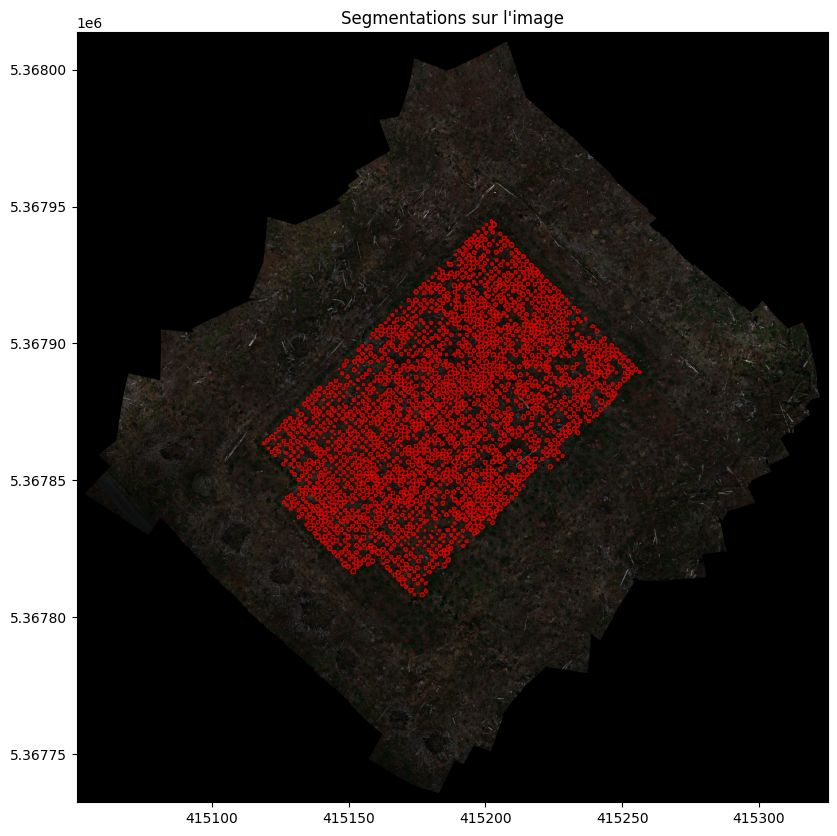

In [15]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np

# Charger l'image
raster_path = f"./preprocessing/cleaning_data/{image_name}_clean.tif"

with rasterio.open(raster_path) as src:
    # Lire les bandes 
    red = src.read(6)
    green = src.read(4)
    blue = src.read(2)

    # Empiler les bandes
    rgb = np.stack((red, green, blue), axis=-1)

    # Sauvegarder les infos de projection et transform pour affichage
    transform = src.transform
    crs = src.crs

# Charger les shapefiles
gdf_annotation = gpd.read_file(f"./preprocessing/raw_data/example_annotation.shp")

# Reprojeter si nécessaire
if gdf_annotation.crs != crs:
    gdf_annotation = gdf_annotation.to_crs(crs)

# Affichage
fig, ax = plt.subplots(figsize=(10, 10))
show(rgb.transpose(2, 0, 1), transform=transform, ax=ax)
gdf_annotation.plot(ax=ax, edgecolor='red', linewidth=1, facecolor='none', alpha=0.7, label="Annotation")
# plt.legend()
plt.title("Segmentations sur l'image")
plt.show()